In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


#step 1) basic exploratory data analysis (EDA)

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
df=pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Dataset/Crop_recommendation.csv")


In [4]:
df

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice
...,...,...,...,...,...,...,...,...
2395,127,37,52,26.487498,81.747937,6.995743,152.702410,sugarcane
2396,83,68,30,32.059849,66.104136,5.569730,182.592077,sugarcane
2397,109,69,69,26.715853,79.706594,7.289843,129.837443,sugarcane
2398,90,43,44,33.193884,89.983837,7.220254,183.994716,sugarcane


In [5]:
df.head(10)

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice
5,69,37,42,23.058049,83.370118,7.073454,251.055000,rice
6,69,55,38,22.708838,82.639414,5.700806,271.324860,rice
7,94,53,40,20.277744,82.894086,5.718627,241.974195,rice
8,89,54,38,24.515881,83.535216,6.685346,230.446236,rice
9,68,58,38,23.223974,83.033227,6.336254,221.209196,rice


In [6]:
df.shape

(2400, 8)

In [7]:
df.isna()

,N,P,K,temperature,humidity,ph,rainfall,label
0,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...
2395,False,False,False,False,False,False,False,False
2396,False,False,False,False,False,False,False,False
2397,False,False,False,False,False,False,False,False
2398,False,False,False,False,False,False,False,False


In [8]:
df.isna().sum()

,0
N,0
P,0
K,0
temperature,0
humidity,0
ph,0
rainfall,0
label,0


In [9]:
df.dtypes

,0
N,int64
P,int64
K,int64
temperature,float64
humidity,float64
ph,float64
rainfall,float64
label,object


In [10]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
2395,False
2396,False
2397,False
2398,False


In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.nunique()

,0
N,141
P,117
K,91
temperature,2400
humidity,2400
ph,2400
rainfall,2400
label,24


In [13]:
df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000
mean,54.684583,53.475417,48.557083,25.512367,71.071117,6.483173,104.385240
std,38.367664,31.823323,48.643304,5.122678,21.751153,0.758106,54.127345
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,22.000000,30.000000,21.000000,22.486409,59.538890,6.002345,65.673030
50%,40.000000,52.000000,35.000000,25.518655,79.791673,6.438870,96.111257
75%,90.000000,68.000000,51.000000,28.570446,88.993158,6.936103,127.813688
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [14]:
label_counts=df['label'].value_counts()
print(label_counts)

label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
wheat          100
sugarcane      100
Name: count, dtype: int64


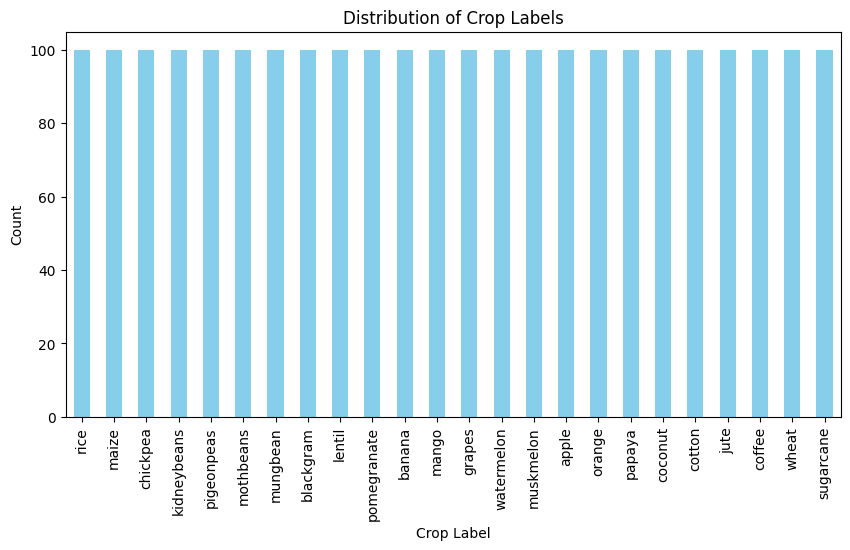

In [15]:
plt.figure(figsize=(10,5))
label_counts.plot(kind='bar',color='skyblue')
plt.xlabel('Crop Label')
plt.ylabel('Count')
plt.title('Distribution of Crop Labels')
plt.show()

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

In [17]:
df.head(3)

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice


In [18]:
X = df[['N',	'P',	'K',	'temperature',	'humidity',	'ph',	'rainfall'	]]

In [19]:
Y = df['label']

In [20]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=42, stratify=Y)

In [21]:
X_train

,N,P,K,temperature,humidity,ph,rainfall
1057,102,73,54,26.402023,84.410076,5.720727,111.016226
770,37,62,17,25.685767,69.843540,7.121255,74.620687
2199,104,18,30,23.603016,60.396475,6.779833,140.937041
164,76,48,18,19.295634,69.634812,5.775978,83.210306
956,7,23,35,19.750885,88.716912,7.054314,102.553804
...,...,...,...,...,...,...,...
353,3,77,25,24.849062,22.894646,5.608165,62.212922
477,0,70,21,36.300497,56.030213,4.672437,101.607399
938,5,24,40,24.692258,93.870301,6.297908,104.673545
1110,18,19,27,27.755187,52.346058,4.772386,94.112133


In [22]:
X_test

,N,P,K,temperature,humidity,ph,rainfall
460,34,75,24,23.502228,51.290195,4.760038,192.302399
685,32,56,21,27.385390,88.666640,6.702772,58.299331
584,20,50,22,30.996947,46.426937,9.406888,38.315979
1851,18,19,29,27.593768,92.485196,6.206078,162.843274
22,67,59,41,21.947667,80.973842,6.012633,213.356092
...,...,...,...,...,...,...,...
1885,30,13,25,27.151161,91.488895,6.413185,164.918223
268,52,56,85,20.118745,14.442283,6.817124,88.681686
1370,97,22,50,26.260287,86.145859,6.769894,58.978788
7,94,53,40,20.277744,82.894086,5.718627,241.974195


In [23]:
Y_train

,label
1057,banana
770,blackgram
2199,coffee
164,maize
956,pomegranate
...,...
353,kidneybeans
477,pigeonpeas
938,pomegranate
1110,mango


In [24]:
Y_test

,label
460,pigeonpeas
685,mungbean
584,mothbeans
1851,coconut
22,rice
...,...
1885,coconut
268,chickpea
1370,watermelon
7,rice


In [25]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [26]:
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_train_scaled_df

,N,P,K,temperature,humidity,ph,rainfall
0,1.234443,0.613912,0.111391,0.174982,0.615828,-1.001542,0.124354
1,-0.461545,0.267824,-0.648474,0.035703,-0.053867,0.825869,-0.549298
2,1.286627,-1.116525,-0.381494,-0.369295,-0.488195,0.380381,0.678164
3,0.556047,-0.172650,-0.627937,-1.206882,-0.063463,-0.929450,-0.390311
4,-1.244309,-0.959212,-0.278810,-1.118357,0.813834,0.738524,-0.032279
...,...,...,...,...,...,...,...
1915,-1.348677,0.739762,-0.484179,-0.126997,-2.212338,-1.148412,-0.778956
1916,-1.426953,0.519524,-0.566326,2.099778,-0.688933,-2.369351,-0.049796
1917,-1.296493,-0.927750,-0.176125,-0.157488,1.050761,-0.248435,0.006956
1918,-0.957295,-1.085062,-0.443105,0.438110,-0.858312,-2.238938,-0.188527


In [27]:
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)
X_test_scaled_df

,N,P,K,temperature,humidity,ph,rainfall
0,-0.539821,0.676837,-0.504715,-0.388894,-0.906855,-2.255050,1.628895
1,-0.592006,0.079049,-0.566326,0.366202,0.811523,0.279833,-0.851393
2,-0.905111,-0.109725,-0.545789,1.068482,-1.130443,3.808165,-1.221269
3,-0.957295,-1.085062,-0.402031,0.406722,0.987081,-0.368255,1.083630
4,0.321218,0.173437,-0.155588,-0.691184,0.457847,-0.620663,2.018582
...,...,...,...,...,...,...,...
475,-0.644190,-1.273837,-0.484179,0.320655,0.941276,-0.098022,1.122036
476,-0.070163,0.079049,0.748035,-1.046825,-2.600934,0.429039,-0.289041
477,1.103982,-0.990675,0.029244,0.147421,0.695630,0.367413,-0.838817
478,1.025706,-0.015338,-0.176125,-1.015907,0.546130,-1.004281,2.548280


In [28]:
models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200,random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Logistic Regression': LogisticRegression(max_iter=200,random_state=42),
    'SVM(RBF Kernel)': SVC(kernel='rbf',random_state=42)
}

In [29]:
results = []
for name,model in models.items():
  if name in ['KNN','Logistic Regression','SVM(RBF Kernel)']:
    model.fit(X_train_scaled,Y_train)
    preds = model.predict(X_test_scaled)
  else:
    model.fit(X_train,Y_train)
    preds = model.predict(X_test)
  acc = accuracy_score(Y_test,preds)
  results.append((name,acc))

In [30]:
results

[('Decision Tree', 0.9791666666666666),
 ('Random Forest', 0.99375),
 ('KNN', 0.9625),
 ('Logistic Regression', 0.9708333333333333),
 ('SVM(RBF Kernel)', 0.9770833333333333)]

In [31]:
result_df = pd.DataFrame(results,columns=['Model','Accuracy'])
result_df

,Model,Accuracy
0,Decision Tree,0.979167
1,Random Forest,0.993750
2,KNN,0.962500
3,Logistic Regression,0.970833
4,SVM(RBF Kernel),0.977083


In [32]:
result_df = result_df.sort_values(by='Accuracy',ascending=False)
result_df

,Model,Accuracy
1,Random Forest,0.993750
0,Decision Tree,0.979167
4,SVM(RBF Kernel),0.977083
3,Logistic Regression,0.970833
2,KNN,0.962500


In [33]:
import pickle as pkl

In [34]:
best_model = RandomForestClassifier(n_estimators=200,random_state=42)
best_model.fit(X_train,Y_train)
preds = best_model.predict(X_test)
acc = accuracy_score(Y_test,preds)
print(f"Best Model Accuuracy: {acc}")

Best Model Accuuracy: 0.99375


In [35]:
best_model.classes_

array(['apple', 'banana', 'blackgram', 'chickpea', 'coconut', 'coffee',
       'cotton', 'grapes', 'jute', 'kidneybeans', 'lentil', 'maize',
       'mango', 'mothbeans', 'mungbean', 'muskmelon', 'orange', 'papaya',
       'pigeonpeas', 'pomegranate', 'rice', 'sugarcane', 'watermelon',
       'wheat'], dtype=object)

In [36]:
bundle = {
    'model': best_model,
    'features_cols': ['N',	'P',	'K',	'temperature',	'humidity',	'ph',	'rainfall'],
    'classes': best_model.classes_
}

In [37]:
with open('Crop_recommendation_rf.pkl','wb') as f:
  pkl.dump(bundle,f)
  print("Model saved as Crop_recommendation_rf.pkl successfully")

Model saved as Crop_recommendation_rf.pkl successfully


In [38]:
with open('Crop_recommendation_rf.pkl','rb') as f:
  b = pkl.load(f)

In [39]:
print(type(b["model"]),b['features_cols'],b['classes'][:3])

<class 'sklearn.ensemble._forest.RandomForestClassifier'> ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall'] ['apple' 'banana' 'blackgram']


In [40]:
sample = {'N':90,	'P':40,	'K':40,	'temperature':20,	'humidity':80,	'ph':7,	'rainfall':200}
X = [[sample[c] for c in b['features_cols']]]
X

[[90, 40, 40, 20, 80, 7, 200]]

In [41]:
print("pred : ",b['model'].predict(X))

pred :  ['rice']


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
